Load necesssary libraries

In [1]:
# load necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns
from adjustText import adjust_text
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    average_precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    brier_score_loss
)
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.base import clone
from sklearn.inspection import permutation_importance

Load Datasets

In [2]:
# import CSVs and add source year column to each dataframe

phil_2023 = pd.read_csv("public_cases_fc_2023.csv", dtype={"zipcode": "string"})
phil_2024 = pd.read_csv("public_cases_fc_2024.csv", dtype={"zipcode": "string"})
phil_2025 = pd.read_csv("public_cases_fc_2025.csv", dtype={"zipcode": "string"})

phil_2023["source_year"] = 2023
phil_2024["source_year"] = 2024
phil_2025["source_year"] = 2025

# combine separate CSVs for each year into one master dataframe

phil_311 = pd.concat(
    [phil_2023, phil_2024, phil_2025],
    ignore_index=True
)

Data Cleaning

In [3]:
# compare columns across years

yearly_data = {
    2023: phil_2023,
    2024: phil_2024,
    2025: phil_2025
}

print(
    "2023 and 2024 columns match:",
    phil_2023.columns.equals(phil_2024.columns)
)

print(
    "2024 and 2025 columns match:",
    phil_2024.columns.equals(phil_2025.columns)
)

all_columns = sorted(
    set().union(*(df.columns for df in yearly_data.values()))
)

column_comparison = pd.DataFrame(
    {
        year: [column in df.columns for column in all_columns]
        for year, df in yearly_data.items()
    },
    index=all_columns
)

column_comparison.index.name = "column"
column_comparison

2023 and 2024 columns match: True
2024 and 2025 columns match: True


,2023,2024,2025
column,,,
address,True,True,True
agency_responsible,True,True,True
closed_datetime,True,True,True
expected_datetime,True,True,True
gdb_geomattr_data,True,True,True
lat,True,True,True
lon,True,True,True
media_url,True,True,True
objectid,True,True,True


In [4]:
# compare data types across years

dtype_comparison = pd.DataFrame(
    {
        year: df.dtypes.astype(str)
        for year, df in yearly_data.items()
    }
).fillna("Column missing")

dtype_comparison.index.name = "column"

dtype_comparison["consistent"] = (
    dtype_comparison[[2023, 2024, 2025]]
    .nunique(axis=1)
    .eq(1)
)

dtype_comparison

,2023,2024,2025,consistent
column,,,,
objectid,int64,int64,int64,True
service_request_id,int64,int64,int64,True
status,object,object,object,True
status_notes,object,object,object,True
service_name,object,object,object,True
service_code,object,object,object,True
agency_responsible,object,object,object,True
service_notice,object,object,object,True
requested_datetime,object,object,object,True


In [5]:
# check shape of each years' dataframe

shape_summary = pd.DataFrame(
    {
        year: {
            "rows": df.shape[0],
            "columns": df.shape[1]
        }
        for year, df in yearly_data.items()
    }
).T

shape_summary.index.name = "source_year"
shape_summary

,rows,columns
source_year,,
2023,518841,21
2024,555892,21
2025,528596,21


In [6]:
# count total rows and unique service request identifiers, also establishes lack of missing values, and lack of duplicates

total_rows = len(phil_311)

unique_requests = phil_311["service_request_id"].nunique()

missing_request_ids = phil_311["service_request_id"].isna().sum()

print(f"Total rows: {total_rows:,}")
print(f"Unique service request IDs: {unique_requests:,}")
print(f"Missing service request IDs: {missing_request_ids:,}")
print(f"Difference between rows and unique IDs: {total_rows - unique_requests:,}")

Total rows: 1,603,329
Unique service request IDs: 1,603,329
Missing service request IDs: 0
Difference between rows and unique IDs: 0


In [7]:
# convert timestamp columns into datetime values

date_columns = [
    "requested_datetime",
    "updated_datetime",
    "expected_datetime",
    "closed_datetime"
]

raw_date_values = phil_311[date_columns].copy()

for column in date_columns:
    phil_311[column] = pd.to_datetime(
        phil_311[column],
        errors="coerce",
        utc=True
    )

# identify invalid date/times

invalid_date_summary = {}

for column in date_columns:
    invalid_mask = (
        raw_date_values[column].notna()
        & phil_311[column].isna()
    )

    invalid_date_summary[column] = invalid_mask.sum()

invalid_date_summary = pd.Series(
    invalid_date_summary,
    name="invalid_timestamp_count"
)

invalid_date_summary

requested_datetime    0
updated_datetime      0
expected_datetime     0
closed_datetime       0
Name: invalid_timestamp_count, dtype: int64

In [8]:
# display date ranges

date_range_summary = pd.DataFrame({
    "earliest": phil_311[date_columns].min(),
    "latest": phil_311[date_columns].max(),
    "missing_count": phil_311[date_columns].isna().sum(),
    "missing_percent": (
        phil_311[date_columns].isna().mean() * 100
    ).round(2)
})

date_range_summary

,earliest,latest,missing_count,missing_percent
requested_datetime,2023-01-01 00:00:25+00:00,2025-12-31 23:51:10+00:00,0,0.00
updated_datetime,2023-01-03 01:03:05+00:00,2026-09-06 06:01:12+00:00,0,0.00
expected_datetime,2023-01-03 00:00:00+00:00,2027-01-15 00:00:00+00:00,939238,58.58
closed_datetime,2023-01-01 08:43:50+00:00,2026-09-06 06:01:12+00:00,54167,3.38


In [9]:
# compare requested-date ranges by year

requested_ranges_by_year = (
    phil_311
    .groupby("source_year")
    .agg(
        earliest_request=("requested_datetime", "min"),
        latest_request=("requested_datetime", "max"),
        request_count=("service_request_id", "size")
    )
)

requested_ranges_by_year

,earliest_request,latest_request,request_count
source_year,,,
2023,2025-01-01 00:00:34+00:00,2025-12-31 23:51:10+00:00,518841
2024,2024-01-01 00:13:37+00:00,2024-12-31 23:57:39+00:00,555892
2025,2023-01-01 00:00:25+00:00,2023-12-31 23:57:59+00:00,528596


In [ ]:
# verify chronological consistency of dates

closed_before_requested = phil_311[
    phil_311["closed_datetime"].notna()
    & (
        phil_311["closed_datetime"]
        < phil_311["requested_datetime"]
    )
]
print(
    "Requests closed before submission:",
    f"{len(closed_before_requested):,}"
)
updated_before_requested = phil_311[
    phil_311["updated_datetime"].notna()
    & (
        phil_311["updated_datetime"]
        < phil_311["requested_datetime"]
    )
]
print(
    "Requests updated before submission:",
    f"{len(updated_before_requested):,}"
)
expected_before_requested = phil_311[
    phil_311["expected_datetime"].notna()
    & (
        phil_311["expected_datetime"]
        < phil_311["requested_datetime"]
    )
]
print(
    "Expected deadlines before submission:",
    f"{len(expected_before_requested):,}"
)

Requests closed before submission: 0
Requests updated before submission: 0
Expected deadlines before submission: 0


In [11]:
# count unique service labels by year

label_count_summary = (
    phil_311
    .groupby("source_year")
    .agg(
        unique_service_types=("service_type", "nunique"),
        unique_agencies=("agency_responsible", "nunique")
    )
)

label_count_summary

,unique_service_types,unique_agencies
source_year,,
2023,84,27
2024,85,54
2025,84,59


In [12]:
# compare service-type availability by year

service_type_counts = pd.crosstab(
    phil_311["service_type"],
    phil_311["source_year"]
)

service_type_counts.head()

source_year,2023,2024,2025
service_type,,,
ADA Curb Ramp,198,213,218
Abandoned Bike,63,92,90
Abandoned Vehicle,27978,33344,31114
Alley Light Outage,1168,2640,3281
Broken Main Drain/Raw Sewage within Property,1575,1418,1494


In [13]:
# identify service types that do not appear in each year

service_type_presence = service_type_counts.gt(0)

service_type_differences = service_type_counts[
    ~service_type_presence.all(axis=1)
]

print(
    "Service types not present in every year:",
    len(service_type_differences)
)

display(service_type_differences)

Service types not present in every year: 17


source_year,2023,2024,2025
service_type,,,
Complaints Against Fire or EMS,0,1,0
Digital Navigator Request,279,0,0
Emergencies,1,0,1
Emergency,0,1,0
Grounds,0,7,128
Homeless Encampment Request,0,3,11
Maintenance Residential,2,0,0
Outdoor Dining Complaint,0,0,1
Parks and Rec Safety and Maintenance,60,0,0


In [14]:
# compare agency availability

agency_counts = pd.crosstab(
    phil_311["agency_responsible"],
    phil_311["source_year"]
)

agency_presence = agency_counts.gt(0)

agency_differences = agency_counts[
    ~agency_presence.all(axis=1)
]

print(
    "Agencies not present in every year:",
    len(agency_differences)
)

display(agency_differences)

Agencies not present in every year: 35


source_year,2023,2024,2025
agency_responsible,,,
Animal Care and Control - ACCT,0,47,368
Behavioral Health and Intellectual Disability Services- DBHIDS,0,10,51
Board of Revision of Taxes- BRT,0,1,1
City Commissioners Office,0,62,396
City Controller,0,1,2
City Planning Commission,0,0,7
City Treasurer's Office,0,1,5
Commerce Department,0,13,28
Ethics Board,0,0,2


In [15]:
# check for whitespace and capitalization inconsistencies

for column in ["service_type", "agency_responsible"]:
    text_values = phil_311[column].dropna().astype(str)

    whitespace_values = text_values[
        text_values.ne(text_values.str.strip())
    ].unique()

    print(f"{column}: {len(whitespace_values)} labels with extra whitespace")
    print(whitespace_values[:20])

for column in ["service_type", "agency_responsible"]:
    label_check = (
        phil_311[[column]]
        .dropna()
        .drop_duplicates()
        .assign(
            normalized_label=lambda df: (
                df[column]
                .astype(str)
                .str.strip()
                .str.casefold()
            )
        )
    )

    possible_duplicates = (
        label_check
        .groupby("normalized_label")
        .filter(lambda group: len(group) > 1)
        .sort_values("normalized_label")
    )

    print(f"\nPossible inconsistent labels in {column}:")
    
    if possible_duplicates.empty:
        print("No capitalization or whitespace inconsistencies found.")
    else:
        display(possible_duplicates)

service_type: 0 labels with extra whitespace
[]
agency_responsible: 0 labels with extra whitespace
[]

Possible inconsistent labels in service_type:
No capitalization or whitespace inconsistencies found.

Possible inconsistent labels in agency_responsible:
No capitalization or whitespace inconsistencies found.


In [16]:
# compare service types across years

service_type_percentages = pd.crosstab(
    phil_311["service_type"],
    phil_311["source_year"],
    normalize="columns"
) * 100

service_type_percentages = (
    service_type_percentages
    .sort_values(2025, ascending=False)
)

service_type_percentages.head(20).round(2)

source_year,2023,2024,2025
service_type,,,
Information Request,55.02,58.63,56.15
Abandoned Vehicle,5.39,6.00,5.89
Illegal Dumping,3.65,4.02,4.31
Rubbish Collection,4.41,3.44,3.29
Graffiti Removal,1.90,1.89,2.77
Street Light Outage,1.37,1.70,2.27
Recyclables Collection,2.53,1.47,1.74
Property Maintenance Exterior,2.04,1.56,1.68
Sanitation Violation,1.45,1.44,1.36


In [17]:
# compare agencies across years

agency_percentages = pd.crosstab(
    phil_311["agency_responsible"],
    phil_311["source_year"],
    normalize="columns"
) * 100

agency_percentages = (
    agency_percentages
    .sort_values(2025, ascending=False)
)

agency_percentages.head(20).round(2)

source_year,2023,2024,2025
agency_responsible,,,
Philly311 Contact Center,55.10,58.31,53.01
Streets Department,23.95,21.38,22.13
License & Inspections,8.80,7.86,9.38
Police Department,5.40,6.05,6.24
Community Life Improvement Program,3.82,3.32,4.26
Parks & Recreation,1.35,1.34,1.38
Water Department (PWD),0.65,0.66,0.82
Fire Department,0.61,0.42,0.62
Office of Homeless Services,0.26,0.43,0.58


In [18]:
# identify largest changes in service type

service_type_percentages["change_2023_to_2025"] = (
    service_type_percentages[2025]
    - service_type_percentages[2023]
)

service_type_percentages.reindex(
    service_type_percentages["change_2023_to_2025"]
    .abs()
    .sort_values(ascending=False)
    .index
).head(20).round(2)

source_year,2023,2024,2025,change_2023_to_2025
service_type,,,,
Information Request,55.02,58.63,56.15,1.13
Rubbish Collection,4.41,3.44,3.29,-1.12
Street Light Outage,1.37,1.70,2.27,0.90
Graffiti Removal,1.90,1.89,2.77,0.87
Recyclables Collection,2.53,1.47,1.74,-0.79
Short Dumping,0.72,0.00,0.00,-0.72
Illegal Dumping,3.65,4.02,4.31,0.66
Abandoned Vehicle,5.39,6.00,5.89,0.49
Licenses,0.19,0.28,0.64,0.45


In [19]:
# identify largest changes in agencies

agency_percentages["change_2023_to_2025"] = (
    agency_percentages[2025]
    - agency_percentages[2023]
)

agency_percentages.reindex(
    agency_percentages["change_2023_to_2025"]
    .abs()
    .sort_values(ascending=False)
    .index
).head(20).round(2)

source_year,2023,2024,2025,change_2023_to_2025
agency_responsible,,,,
Philly311 Contact Center,55.10,58.31,53.01,-2.09
Streets Department,23.95,21.38,22.13,-1.81
Police Department,5.40,6.05,6.24,0.83
License & Inspections,8.80,7.86,9.38,0.58
Community Life Improvement Program,3.82,3.32,4.26,0.44
Office of Homeless Services,0.26,0.43,0.58,0.31
Water Department (PWD),0.65,0.66,0.82,0.17
First Judicial District/Courts,0.00,0.03,0.17,0.17
Revenue,0.00,0.02,0.16,0.16


Define the Analytical Population   

In [20]:
# identify information-related labels

information_labels = (
    phil_311.loc[
        phil_311["service_type"]
        .str.contains("information", case=False, na=False),
        "service_type"
    ]
    .value_counts()
)

information_labels

service_type
Information Request    908148
Name: count, dtype: int64

In [21]:
# create boolean flag for information requests

information_only_mask = (
    phil_311["service_type"]
    .str.strip()
    .str.casefold()
    .eq("information request")
)

# count excluded information requests

information_request_summary = (
    phil_311.loc[information_only_mask]
    .groupby("source_year")
    .size()
    .rename("information_only_requests")
    .to_frame()
)

information_request_summary.loc["Total"] = (
    information_request_summary[
        "information_only_requests"
    ].sum()
)

information_request_summary

,information_only_requests
source_year,
2023,285458
2024,325906
2025,296784
Total,908148


In [22]:
# create operational dataset that excludes information requests

operational_311 = phil_311.loc[
    ~information_only_mask
].copy()

# verify removal of information requests

print(f"Original records: {len(phil_311):,}")
print(f"Information-only requests removed: {information_only_mask.sum():,}")
print(f"Operational records retained: {len(operational_311):,}")

remaining_information_requests = (
    operational_311["service_type"]
    .str.strip()
    .str.casefold()
    .eq("information request")
    .sum()
)

print(
    "Information-only requests remaining:",
    remaining_information_requests
)

Original records: 1,603,329
Information-only requests removed: 908,148
Operational records retained: 695,181
Information-only requests remaining: 0


In [23]:
# summarize missing dates

required_date_summary = (
    operational_311
    .groupby("source_year")
    .agg(
        total_records=("service_request_id", "size"),
        missing_requested_date=(
            "requested_datetime",
            lambda x: x.isna().sum()
        ),
        missing_expected_date=(
            "expected_datetime",
            lambda x: x.isna().sum()
        )
    )
)

required_date_summary

,total_records,missing_requested_date,missing_expected_date
source_year,,,
2023,233383,0,11717
2024,229986,0,13720
2025,231812,0,12611


In [ ]:
# exclude observations without valid dates

valid_required_dates = (
    operational_311["requested_datetime"].notna()
    & operational_311["expected_datetime"].notna()
)
eligible_by_year = (
    operational_311.loc[valid_required_dates]
    .groupby("source_year")
    .size()
)
required_date_summary["eligible_records"] = eligible_by_year
required_date_summary["excluded_records"] = (
    required_date_summary["total_records"]
    - required_date_summary["eligible_records"]
)
required_date_summary["percent_retained"] = (
    required_date_summary["eligible_records"]
    / required_date_summary["total_records"]
    * 100
).round(2)
required_date_summary
deadline_eligible_311 = operational_311.loc[
    valid_required_dates
].copy()

print(f"Operational records before date filtering: {len(operational_311):,}")
print(f"Records excluded for missing required dates: {(~valid_required_dates).sum():,}")
print(f"Deadline-eligible records retained: {len(deadline_eligible_311):,}")
print(
    "Missing requested dates:",
    deadline_eligible_311["requested_datetime"].isna().sum()
)
print(
    "Missing expected dates:",
    deadline_eligible_311["expected_datetime"].isna().sum()
)

Operational records before date filtering: 695,181
Records excluded for missing required dates: 38,048
Deadline-eligible records retained: 657,133
Missing requested dates: 0
Missing expected dates: 0


In [25]:
# identify whether each request was closed or remains open

deadline_eligible_311["status"].value_counts(dropna=False)

deadline_eligible_311["status_normalized"] = (
    deadline_eligible_311["status"]
    .astype("string")
    .str.strip()
    .str.casefold()
)

deadline_eligible_311["status_normalized"].value_counts(
    dropna=False
)

status_normalized
closed    611746
open       45387
Name: count, dtype: Int64

In [26]:
# compare closure status with the closure timestamp

deadline_eligible_311["has_closed_datetime"] = (
    deadline_eligible_311["closed_datetime"].notna()
)

status_closure_comparison = pd.crosstab(
    deadline_eligible_311["status_normalized"],
    deadline_eligible_311["has_closed_datetime"],
    margins=True
)

status_closure_comparison

has_closed_datetime,False,True,All
status_normalized,,,
closed,0,611746,611746
open,45387,0,45387
All,45387,611746,657133


In [27]:
# for closed requests:  
# mark request late if closed date is after expected date  
# mark request on time if closed date is on or before expected date

deadline_eligible_311["missed_deadline"] = pd.Series(
    pd.NA,
    index=deadline_eligible_311.index,
    dtype="boolean"
)

deadline_eligible_311["is_closed"] = (
    deadline_eligible_311["closed_datetime"].notna()
)

closed_mask = deadline_eligible_311["is_closed"]

deadline_eligible_311.loc[
    closed_mask,
    "missed_deadline"
] = (
    deadline_eligible_311.loc[
        closed_mask,
        "closed_datetime"
    ].dt.normalize()
    >
    deadline_eligible_311.loc[
        closed_mask,
        "expected_datetime"
    ].dt.normalize()
)

closed_deadline_summary = (
    deadline_eligible_311.loc[closed_mask]
    ["missed_deadline"]
    .value_counts(dropna=False)
)

closed_deadline_summary

missed_deadline
False    348045
True     263701
Name: count, dtype: Int64

In [28]:
# for open requests:  
# mark request late if its expected date has already passed  
# exclude request if its expected date has not yet passed

# establish dataset snapshot date

snapshot_date = pd.Timestamp(
    "2026-09-09",
    tz="UTC"
)

In [29]:
# create open request masks

open_mask = ~deadline_eligible_311["is_closed"]

open_past_deadline_mask = (
    open_mask
    & (
        deadline_eligible_311[
            "expected_datetime"
        ].dt.normalize()
        < snapshot_date
    )
)

open_not_yet_due_mask = (
    open_mask
    & (
        deadline_eligible_311[
            "expected_datetime"
        ].dt.normalize()
        >= snapshot_date
    )
)

# mark overdue open requests as missed deadline

deadline_eligible_311.loc[
    open_past_deadline_mask,
    "missed_deadline"
] = True

# review open request results

print(f"Total open requests: {open_mask.sum():,}")

print(
    "Open requests already past deadline:",
    f"{open_past_deadline_mask.sum():,}"
)

print(
    "Open requests not yet due:",
    f"{open_not_yet_due_mask.sum():,}"
)

Total open requests: 45,387
Open requests already past deadline: 45,383
Open requests not yet due: 4


In [30]:
# exclude open requests that have not reached their deadline

modeling_311 = deadline_eligible_311.dropna(
    subset=["missed_deadline"]
).copy()

modeling_311["missed_deadline"] = (
    modeling_311["missed_deadline"]
    .astype("int8")
)

print(
    "Deadline-eligible records:",
    f"{len(deadline_eligible_311):,}"
)

print(
    "Records with known outcomes:",
    f"{len(modeling_311):,}"
)

print(
    "Open, not-yet-due records excluded:",
    f"{open_not_yet_due_mask.sum():,}"
)

Deadline-eligible records: 657,133
Records with known outcomes: 657,129
Open, not-yet-due records excluded: 4


Data Exploration 

In [31]:
# calculate request counts by year

yearly_request_counts = (
    modeling_311
    .groupby("source_year")
    .size()
    .rename("request_count")
    .reset_index()
)

yearly_request_counts

,source_year,request_count
0,2023,221662
1,2024,216266
2,2025,219201


In [32]:
# add yearly percentage of modeling population

yearly_request_counts["percent_of_total"] = (
    yearly_request_counts["request_count"]
    / yearly_request_counts["request_count"].sum()
    * 100
).round(2)

yearly_request_counts

,source_year,request_count,percent_of_total
0,2023,221662,33.73
1,2024,216266,32.91
2,2025,219201,33.36


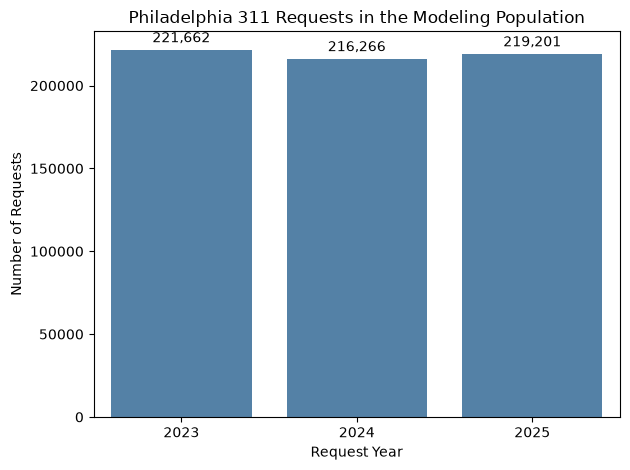

In [33]:
# plot bar chart of requests by year

ax = sns.barplot(
    data=yearly_request_counts,
    x="source_year",
    y="request_count",
    color="steelblue"
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f"{value:,.0f}"
            for value in container.datavalues
        ],
        padding=3
    )

plt.title("Philadelphia 311 Requests in the Modeling Population")
plt.xlabel("Request Year")
plt.ylabel("Number of Requests")
plt.ticklabel_format(
    style="plain",
    axis="y"
)
plt.tight_layout()
plt.show()

In [34]:
# calculate late-resolution rates by year

late_rates_by_year = (
    modeling_311
    .groupby("source_year")
    .agg(
        total_requests=("service_request_id", "size"),
        late_requests=("missed_deadline", "sum"),
        late_rate=("missed_deadline", "mean")
    )
    .reset_index()
)

late_rates_by_year["on_time_requests"] = (
    late_rates_by_year["total_requests"]
    - late_rates_by_year["late_requests"]
)

late_rates_by_year["late_rate_percent"] = (
    late_rates_by_year["late_rate"] * 100
).round(2)

late_rates_by_year

,source_year,total_requests,late_requests,late_rate,on_time_requests,late_rate_percent
0,2023,221662,99020,0.446716,122642,44.67
1,2024,216266,105703,0.488764,110563,48.88
2,2025,219201,104361,0.476097,114840,47.61


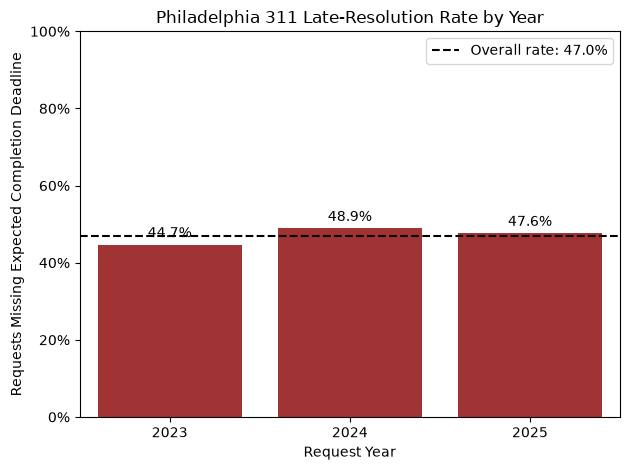

In [35]:
# plot the late resolution rate by year

overall_late_rate = modeling_311["missed_deadline"].mean()

ax = sns.barplot(
    data=late_rates_by_year,
    x="source_year",
    y="late_rate",
    color="firebrick"
)

# Add percentage labels above each bar
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f"{value:.1%}"
            for value in container.datavalues
        ],
        padding=3
    )

# Show the overall late-resolution rate
ax.axhline(
    overall_late_rate,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=f"Overall rate: {overall_late_rate:.1%}"
)

ax.yaxis.set_major_formatter(
    PercentFormatter(1.0)
)

ax.set_ylim(0, 1)

plt.title("Philadelphia 311 Late-Resolution Rate by Year")
plt.xlabel("Request Year")
plt.ylabel("Requests Missing Expected Completion Deadline")
plt.legend()
plt.tight_layout()
plt.show()

In [36]:
# calculate request counts and late rates by service type

service_type_summary = (
    modeling_311
    .groupby("service_type", dropna=False)
    .agg(
        request_count=("service_request_id", "size"),
        late_requests=("missed_deadline", "sum"),
        late_rate=("missed_deadline", "mean")
    )
    .reset_index()
)

service_type_summary["on_time_requests"] = (
    service_type_summary["request_count"]
    - service_type_summary["late_requests"]
)

service_type_summary["late_rate_percent"] = (
    service_type_summary["late_rate"] * 100
).round(2)

service_type_summary = service_type_summary.sort_values(
    "request_count",
    ascending=False
)

service_type_summary.head(20)

,service_type,request_count,late_requests,late_rate,on_time_requests,late_rate_percent
2,Abandoned Vehicle,92436,52433,0.567236,40003,56.72
26,Illegal Dumping,64044,24608,0.384236,39436,38.42
53,Rubbish Collection,59439,33361,0.561264,26078,56.13
21,Graffiti Removal,35023,6652,0.189932,28371,18.99
49,Recyclables Collection,30520,16073,0.526638,14447,52.66
63,Street Light Outage,28558,9988,0.349744,18570,34.97
45,Property Maintenance Exterior,28104,18205,0.647773,9899,64.78
54,Sanitation Violation,22729,7339,0.322891,15390,32.29
73,Vacant Lot,20675,1244,0.060169,19431,6.02
37,Other (Streets),20100,11405,0.567413,8695,56.74


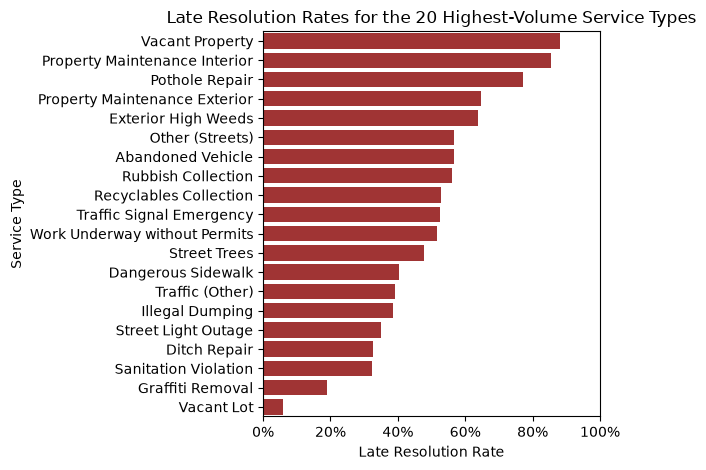

In [37]:
# plot late resolution rates by service type

top_service_types = service_type_summary.head(20).sort_values(
    "late_rate",
    ascending=False
)

ax = sns.barplot(
    data=top_service_types,
    x="late_rate",
    y="service_type",
    color="firebrick"
)

ax.xaxis.set_major_formatter(PercentFormatter(1.0))

plt.xlabel("Late Resolution Rate")
plt.ylabel("Service Type")
plt.title("Late Resolution Rates for the 20 Highest-Volume Service Types")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

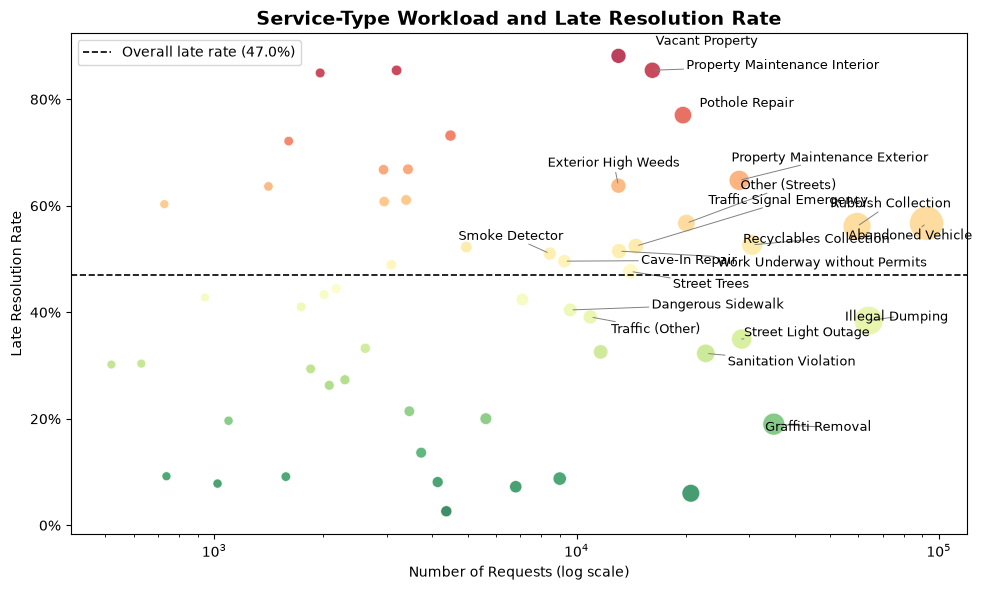

In [99]:
# scatterplot of late resolution by service type, excluding small categories

minimum_requests = 500

service_type_plot = service_type_summary.loc[
    service_type_summary["request_count"] >= minimum_requests
].copy()

# prioritize categories that combine volume and lateness
service_type_plot["impact_score"] = (
    service_type_plot["request_count"]
    * service_type_plot["late_rate"]
)

labels_to_show = service_type_plot.nlargest(
    20, "impact_score"
)

ax = sns.scatterplot(
    data=service_type_plot,
    x="request_count",
    y="late_rate",
    size="request_count",
    hue="late_rate",
    palette="RdYlGn_r",
    sizes=(40, 600),
    alpha=0.75,
    legend=False
)

overall_late_rate = modeling_311["missed_deadline"].mean()

ax.axhline(
    overall_late_rate,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=f"Overall late rate ({overall_late_rate:.1%})"
)

texts = []

for _, row in labels_to_show.iterrows():
    texts.append(
        ax.text(
            row["request_count"],
            row["late_rate"],
            row["service_type"],
            fontsize=9
        )
    )

adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(
        arrowstyle="-",
        color="gray",
        linewidth=0.7
    )
)

ax.set_xscale("log")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

ax.set_xlabel("Number of Requests (log scale)")
ax.set_ylabel("Late Resolution Rate")
ax.set_title(
    "Service-Type Workload and Late Resolution Rate",
    fontsize=14,
    fontweight="bold"
)
ax.figure.set_size_inches(10, 6)
ax.legend()
plt.tight_layout()
plt.show()

In [39]:
service_type_by_year = (
    modeling_311
    .groupby(["source_year", "service_type"])
    .agg(
        request_count=("service_request_id", "size"),
        late_requests=("missed_deadline", "sum"),
        late_rate=("missed_deadline", "mean")
    )
    .reset_index()
)

service_type_by_year["late_rate_percent"] = (
    service_type_by_year["late_rate"] * 100
).round(2)

service_type_by_year.head()

,source_year,service_type,request_count,late_requests,late_rate,late_rate_percent
0,2023,ADA Curb Ramp,198,58,0.292929,29.29
1,2023,Abandoned Bike,59,15,0.254237,25.42
2,2023,Abandoned Vehicle,27978,19471,0.695940,69.59
3,2023,Alley Light Outage,1168,1100,0.941781,94.18
4,2023,Broken Main Drain/Raw Sewage within Property,1575,1092,0.693333,69.33


In [40]:
# calculate request counts and late rates by agency

agency_summary = (
    modeling_311
    .groupby("agency_responsible", dropna=False)
    .agg(
        request_count=("service_request_id", "size"),
        late_requests=("missed_deadline", "sum"),
        late_rate=("missed_deadline", "mean")
    )
    .reset_index()
)

agency_summary["on_time_requests"] = (
    agency_summary["request_count"]
    - agency_summary["late_requests"]
)

agency_summary["late_rate_percent"] = (
    agency_summary["late_rate"] * 100
).round(2)

agency_summary = agency_summary.sort_values(
    "request_count",
    ascending=False
)

agency_summary

,agency_responsible,request_count,late_requests,late_rate,on_time_requests,late_rate_percent
8,Streets Department,350163,157787,0.450610,192376,45.06
2,License & Inspections,105905,73100,0.690241,32805,69.02
7,Police Department,92629,52434,0.566065,40195,56.61
0,Community Life Improvement Program,60178,8646,0.143674,51532,14.37
5,Parks & Recreation,20880,11021,0.527826,9859,52.78
9,Water Department (PWD),10591,932,0.087999,9659,8.80
1,Fire Department,8552,4418,0.516604,4134,51.66
3,Office of Homeless Services,6794,492,0.072417,6302,7.24
6,Philly311 Contact Center,1158,247,0.213299,911,21.33
4,Office of Information & Technology,279,7,0.025090,272,2.51


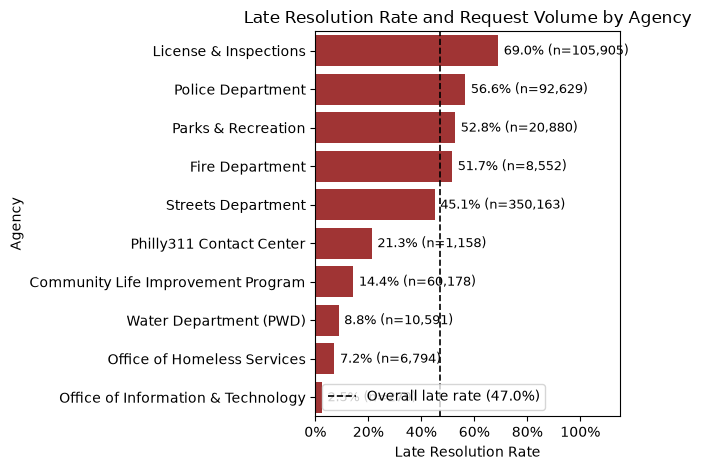

In [41]:
# plot agency late rates with counts of requests

agency_plot = agency_summary.sort_values(
    "late_rate",
    ascending=False
).copy()

agency_plot["chart_label"] = agency_plot.apply(
    lambda row: (
        f'{row["late_rate"]:.1%} '
        f'(n={row["request_count"]:,})'
    ),
    axis=1
)

ax = sns.barplot(
    data=agency_plot,
    x="late_rate",
    y="agency_responsible",
    color="firebrick"
)

ax.axvline(
    overall_late_rate,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=f"Overall late rate ({overall_late_rate:.1%})"
)

ax.bar_label(
    ax.containers[0],
    labels=agency_plot["chart_label"],
    padding=4,
    fontsize=9
)

ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlim(0, 1.15)
ax.set_xlabel("Late Resolution Rate")
ax.set_ylabel("Agency")
ax.set_title("Late Resolution Rate and Request Volume by Agency")
ax.legend()

plt.tight_layout()
plt.show()

In [42]:
# create intake-time features

modeling_311["request_month"] = modeling_311["requested_datetime"].dt.month
modeling_311["request_month_name"] = modeling_311["requested_datetime"].dt.month_name()

modeling_311["request_day_of_week"] = modeling_311["requested_datetime"].dt.day_name()
modeling_311["request_hour"] = modeling_311["requested_datetime"].dt.hour

modeling_311["request_year_month"] = (
    modeling_311["requested_datetime"].dt.to_period("M").astype(str)
)

/var/folders/hw/sky31qc51b35ln00rl2yqswr0000gn/T/ipykernel_49779/183160335.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  modeling_311["requested_datetime"].dt.to_period("M").astype(str)


In [43]:
# examine monthly patterns

month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_summary = (
    modeling_311
    .groupby("request_month_name")
    .agg(
        request_count=("service_request_id", "size"),
        late_requests=("missed_deadline", "sum"),
        late_rate=("missed_deadline", "mean")
    )
    .reindex(month_order)
    .reset_index()
)

monthly_summary["late_rate_percent"] = (
    monthly_summary["late_rate"] * 100
).round(2)

monthly_summary



,request_month_name,request_count,late_requests,late_rate,late_rate_percent
0,January,52848,25779,0.487795,48.78
1,February,45470,22290,0.490213,49.02
2,March,55021,24053,0.437160,43.72
3,April,56848,24060,0.423234,42.32
4,May,61111,26375,0.431592,43.16
5,June,60366,29670,0.491502,49.15
6,July,71784,34342,0.478407,47.84
7,August,68157,33893,0.497278,49.73
8,September,54176,26909,0.496696,49.67
9,October,49563,22624,0.456470,45.65


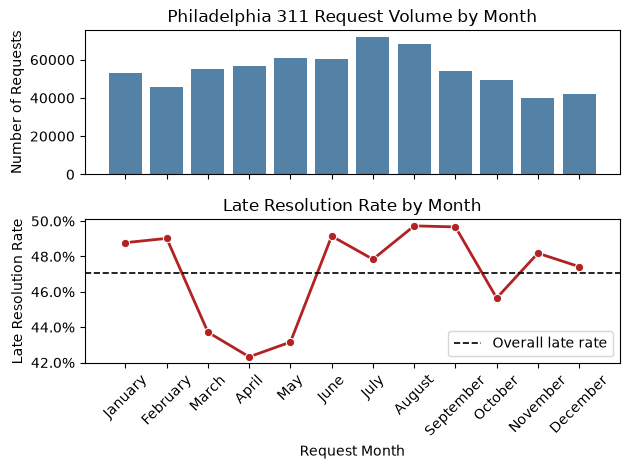

In [44]:
# plot monthly patterns

fig, axes = plt.subplots(2, 1, sharex=True)

sns.barplot(
    data=monthly_summary,
    x="request_month_name",
    y="request_count",
    color="steelblue",
    ax=axes[0]
)

axes[0].set_title("Philadelphia 311 Request Volume by Month")
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of Requests")
axes[0].ticklabel_format(style="plain", axis="y")

sns.lineplot(
    data=monthly_summary,
    x="request_month_name",
    y="late_rate",
    marker="o",
    linewidth=2,
    color="firebrick",
    ax=axes[1]
)

axes[1].axhline(
    modeling_311["missed_deadline"].mean(),
    color="black",
    linestyle="--",
    linewidth=1.2,
    label="Overall late rate"
)

axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].set_xlabel("Request Month")
axes[1].set_ylabel("Late Resolution Rate")
axes[1].set_title("Late Resolution Rate by Month")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

In [45]:
# examine weekly patterns

day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

weekday_summary = (
    modeling_311
    .groupby("request_day_of_week")
    .agg(
        request_count=("service_request_id", "size"),
        late_requests=("missed_deadline", "sum"),
        late_rate=("missed_deadline", "mean")
    )
    .reindex(day_order)
    .reset_index()
)

weekday_summary["late_rate_percent"] = (
    weekday_summary["late_rate"] * 100
).round(2)

weekday_summary

,request_day_of_week,request_count,late_requests,late_rate,late_rate_percent
0,Monday,121816,57722,0.473846,47.38
1,Tuesday,127376,60948,0.478489,47.85
2,Wednesday,125779,59348,0.471843,47.18
3,Thursday,118062,56241,0.476368,47.64
4,Friday,104488,48793,0.466972,46.70
5,Saturday,31095,13787,0.443383,44.34
6,Sunday,28513,12245,0.429453,42.95


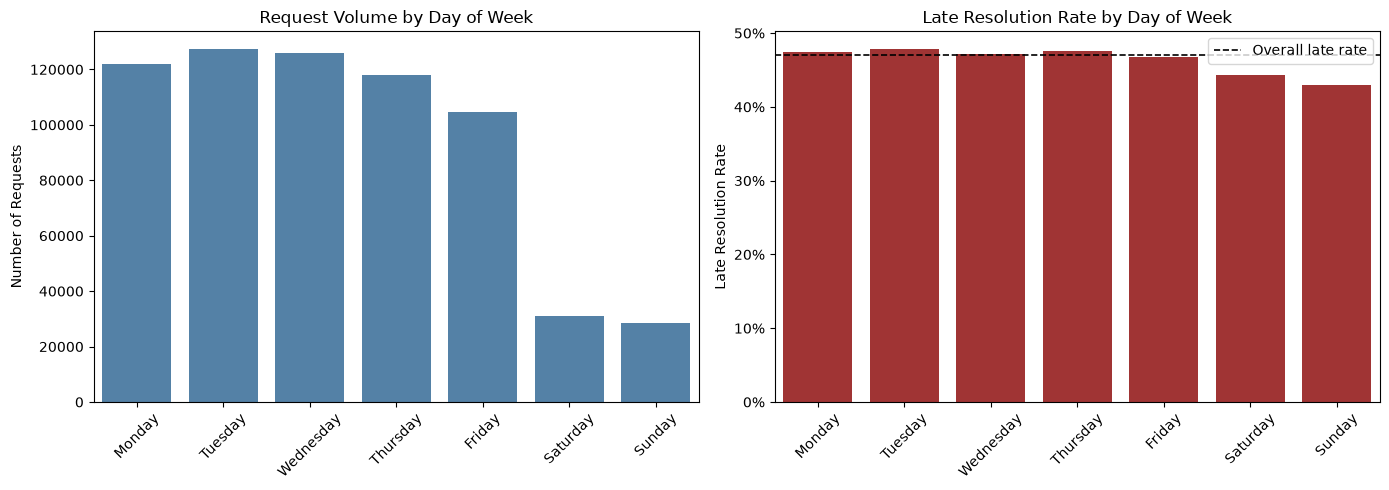

In [46]:
# plot weekly patterns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=weekday_summary,
    x="request_day_of_week",
    y="request_count",
    color="steelblue",
    ax=axes[0]
)

axes[0].set_title("Request Volume by Day of Week")
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of Requests")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(
    data=weekday_summary,
    x="request_day_of_week",
    y="late_rate",
    color="firebrick",
    ax=axes[1]
)

axes[1].axhline(
    modeling_311["missed_deadline"].mean(),
    color="black",
    linestyle="--",
    linewidth=1.2,
    label="Overall late rate"
)

axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].set_title("Late Resolution Rate by Day of Week")
axes[1].set_xlabel("")
axes[1].set_ylabel("Late Resolution Rate")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

In [47]:
# check geographic data completeness

geographic_quality = pd.Series({
    "total_requests": len(modeling_311),
    "missing_zip_codes": modeling_311["zipcode"].isna().sum(),
    "valid_zip_codes": modeling_311["zipcode"].notna().sum(),
    "unique_zip_codes": modeling_311["zipcode"].nunique()
})

geographic_quality["percent_missing"] = (
    geographic_quality["missing_zip_codes"]
    / geographic_quality["total_requests"]
    * 100
)

geographic_quality



total_requests       657129.00000
missing_zip_codes     19953.00000
valid_zip_codes      637176.00000
unique_zip_codes         62.00000
percent_missing           3.03639
dtype: float64

In [48]:
# standardize ZIP codes

modeling_311["zipcode_clean"] = (
    modeling_311["zipcode"]
    .astype("string")
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
    .str.extract(r"(\d{5})", expand=False)
)

In [49]:
# investigate unusually short or long resolution times

closed_requests = modeling_311.loc[
    modeling_311["is_closed"]
].copy()

closed_requests["resolution_hours"] = (
    closed_requests["closed_datetime"]
    - closed_requests["requested_datetime"]
).dt.total_seconds() / 3600

closed_requests["resolution_days"] = (
    closed_requests["resolution_hours"] / 24
)

closed_requests["resolution_days"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

count    611746.000000
mean         85.632977
std         167.059227
min           0.000000
1%            0.013327
5%            0.828333
25%           3.525770
50%          11.620926
75%          72.102708
95%         456.265767
99%         835.109621
max        1336.212303
Name: resolution_days, dtype: float64

In [50]:
# identify invalid or unusually short resolution durations

resolution_time_checks = pd.Series({
    "closed_requests": len(closed_requests),
    "negative_resolution_times":
        (closed_requests["resolution_hours"] < 0).sum(),
    "zero_resolution_times":
        (closed_requests["resolution_hours"] == 0).sum(),
    "resolved_within_one_hour":
        closed_requests["resolution_hours"].between(
            0, 1, inclusive="right"
        ).sum(),
    "resolved_within_one_day":
        closed_requests["resolution_hours"].between(
            0, 24, inclusive="right"
        ).sum()
})

resolution_time_checks

closed_requests              611746
negative_resolution_times         0
zero_resolution_times          3560
resolved_within_one_hour       4889
resolved_within_one_day       41686
dtype: int64

Create Intake-Time Features

In [51]:
# calculate expected service period assigned at intake

modeling_311["expected_service_hours"] = (
    modeling_311["expected_datetime"]
    - modeling_311["requested_datetime"]
).dt.total_seconds() / 3600

modeling_311["expected_service_days"] = (
    modeling_311["expected_service_hours"] / 24
)

# define initial intake-time feature list

intake_features = [
    "service_type",
    "service_code",
    "agency_responsible",
    "zipcode_clean",
    "expected_service_days"
]

target = "missed_deadline"

modeling_data = modeling_311[
    intake_features + [target, "source_year"]
].copy()

# derive time features from intake time

modeling_311["request_year"] = (
    modeling_311["requested_datetime"].dt.year
)

modeling_311["request_month"] = (
    modeling_311["requested_datetime"].dt.month
)

modeling_311["request_day_of_week"] = (
    modeling_311["requested_datetime"].dt.day_name()
)

modeling_311["request_hour"] = (
    modeling_311["requested_datetime"].dt.hour
)

modeling_311["is_weekend"] = (
    modeling_311["requested_datetime"].dt.dayofweek >= 5
).astype("int8")

# derive seasons from months

season_map = {
    12: "Winter",
    1: "Winter",
    2: "Winter",
    3: "Spring",
    4: "Spring",
    5: "Spring",
    6: "Summer",
    7: "Summer",
    8: "Summer",
    9: "Fall",
    10: "Fall",
    11: "Fall"
}

modeling_311["request_season"] = (
    modeling_311["request_month"].map(season_map)
)

Split Data into Training, Validation, and Testing Splits

In [52]:
# define feature columns

categorical_features = [
    "service_type",
    "service_code",
    "agency_responsible",
    "zipcode_clean",
    "request_month",
    "request_day_of_week",
    "request_hour"
]

numeric_features = [
    "is_weekend",
    "expected_service_days"
]

feature_columns = categorical_features + numeric_features
target = "missed_deadline"

In [53]:
# split data into training, validation, and testing splits

train_data = modeling_311.loc[
    modeling_311["source_year"] == 2023
].copy()

validation_data = modeling_311.loc[
    modeling_311["source_year"] == 2024
].copy()

test_data = modeling_311.loc[
    modeling_311["source_year"] == 2025
].copy()

In [54]:
# separate predictors and target variable

X_train = train_data[feature_columns]
y_train = train_data[target]

X_validation = validation_data[feature_columns]
y_validation = validation_data[target]

X_test = test_data[feature_columns]
y_test = test_data[target]

In [55]:
# verify the splits

split_summary = pd.DataFrame({
    "split": ["Training", "Validation", "Testing"],
    "year": [2023, 2024, 2025],
    "observations": [
        len(X_train),
        len(X_validation),
        len(X_test)
    ],
    "late_rate": [
        y_train.mean(),
        y_validation.mean(),
        y_test.mean()
    ]
})

split_summary["late_rate_percent"] = (
    split_summary["late_rate"] * 100
).round(2)

split_summary

,split,year,observations,late_rate,late_rate_percent
0,Training,2023,221662,0.446716,44.67
1,Validation,2024,216266,0.488764,48.88
2,Testing,2025,219201,0.476097,47.61


In [56]:
# standardize all categorical model inputs

X_train = X_train.copy()
X_validation = X_validation.copy()
X_test = X_test.copy()

for dataset in [X_train, X_validation, X_test]:
    for column in categorical_features:
        dataset[column] = (
            dataset[column]
            .astype("string")
            .fillna("Unknown")
            .astype(str)
        )

Prepare Model Inputs

In [57]:
# determine missing values in each split

missing_by_split = pd.DataFrame({
    "training_2023": X_train[feature_columns].isna().sum(),
    "validation_2024": X_validation[feature_columns].isna().sum(),
    "testing_2025": X_test[feature_columns].isna().sum()
})

missing_by_split

,training_2023,validation_2024,testing_2025
service_type,0,0,0
service_code,0,0,0
agency_responsible,0,0,0
zipcode_clean,0,0,0
request_month,0,0,0
request_day_of_week,0,0,0
request_hour,0,0,0
is_weekend,0,0,0
expected_service_days,0,0,0


In [58]:
# create preprocessing pipelines

categorical_pipeline = Pipeline([
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

preprocessor = ColumnTransformer([
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    ),
    (
        "numeric",
        numeric_pipeline,
        numeric_features
    )
])

logistic_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

Establish No-Skill Baseline  

In [59]:
# fit a naive classifier using the training data

naive_classifier = DummyClassifier(
    strategy="prior"
)

naive_classifier.fit(X_train, y_train)

naive_validation_predictions = naive_classifier.predict(
    X_validation
)

naive_validation_probabilities = (
    naive_classifier.predict_proba(X_validation)[:, 1]
)

In [60]:
# evaluate the naive classifier

naive_validation_metrics = {
    "accuracy": accuracy_score(
        y_validation,
        naive_validation_predictions
    ),
    "precision": precision_score(
        y_validation,
        naive_validation_predictions,
        zero_division=0
    ),
    "recall": recall_score(
        y_validation,
        naive_validation_predictions,
        zero_division=0
    ),
    "f1_score": f1_score(
        y_validation,
        naive_validation_predictions,
        zero_division=0
    ),
    "roc_auc": roc_auc_score(
        y_validation,
        naive_validation_probabilities
    )
}

pd.Series(naive_validation_metrics)

accuracy     0.511236
precision    0.000000
recall       0.000000
f1_score     0.000000
roc_auc      0.500000
dtype: float64

In [61]:
# generate confusion matrix for naive classifier

naive_validation_confusion_matrix = confusion_matrix(
    y_validation,
    naive_validation_predictions
)

naive_validation_confusion_matrix

array([[110563,      0],
       [105703,      0]])

In [62]:
# confirm that the naive classifier ROC-AUC equals 0.50

print(
    "Training late rate:",
    f"{y_train.mean():.4f}"
)

print(
    "Naive predicted late probability:",
    f"{naive_validation_probabilities[0]:.4f}"
)

print(
    "Naive validation ROC-AUC:",
    f"{naive_validation_metrics['roc_auc']:.4f}"
)

Training late rate: 0.4467
Naive predicted late probability: 0.4467
Naive validation ROC-AUC: 0.5000


Train Logistic Regression 

In [63]:
# fit logistic regression using 2023 data

logistic_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int8](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['service_type','service_code','agency_responsible',...,'request_hour', 'is_weekend','expected_service_days']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).

In [64]:
# generate validation predictions for 2024

logistic_validation_predictions = (
    logistic_pipeline.predict(X_validation)
)

logistic_validation_probabilities = (
    logistic_pipeline.predict_proba(X_validation)[:, 1]
)

In [65]:
# calculate logistic validation features

logistic_validation_metrics = {
    "accuracy": accuracy_score(
        y_validation,
        logistic_validation_predictions
    ),
    "precision": precision_score(
        y_validation,
        logistic_validation_predictions,
        zero_division=0
    ),
    "recall": recall_score(
        y_validation,
        logistic_validation_predictions,
        zero_division=0
    ),
    "f1_score": f1_score(
        y_validation,
        logistic_validation_predictions,
        zero_division=0
    ),
    "roc_auc": roc_auc_score(
        y_validation,
        logistic_validation_probabilities
    )
}

pd.Series(logistic_validation_metrics).round(4)

accuracy     0.6423
precision    0.6477
recall       0.5879
f1_score     0.6164
roc_auc      0.7075
dtype: float64

Train Gradient-Boosting Model

In [66]:
# create gradient boosting pipeline

gb_numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    )
])

gb_preprocessor = ColumnTransformer([
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    ),
    (
        "numeric",
        gb_numeric_pipeline,
        numeric_features
    )
])

In [67]:
# create initial gradient boosting model

gradient_boosting_pipeline = Pipeline([
    (
        "preprocessor",
        gb_preprocessor
    ),
    (
        "model",
        GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        )
    )
])

In [68]:
# fit gradient boosting model using 2023 training data

gradient_boosting_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int8](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['service_type','service_code','agency_responsible',...,'request_hour', 'is_weekend','expected_service_days']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).

In [69]:
# evaluate gradient boosting model on 2024 data

gb_validation_predictions = (
    gradient_boosting_pipeline.predict(X_validation)
)

gb_validation_probabilities = (
    gradient_boosting_pipeline.predict_proba(
        X_validation
    )[:, 1]
)

In [70]:
gb_validation_metrics = {
    "accuracy": accuracy_score(
        y_validation,
        gb_validation_predictions
    ),
    "precision": precision_score(
        y_validation,
        gb_validation_predictions,
        zero_division=0
    ),
    "recall": recall_score(
        y_validation,
        gb_validation_predictions,
        zero_division=0
    ),
    "f1_score": f1_score(
        y_validation,
        gb_validation_predictions,
        zero_division=0
    ),
    "roc_auc": roc_auc_score(
        y_validation,
        gb_validation_probabilities
    )
}

pd.Series(gb_validation_metrics).round(4)

accuracy     0.6359
precision    0.6596
recall       0.5270
f1_score     0.5859
roc_auc      0.6965
dtype: float64

In [71]:
validation_model_comparison = pd.DataFrame({
    "Naive classifier": naive_validation_metrics,
    "Logistic regression": logistic_validation_metrics,
    "Gradient boosting": gb_validation_metrics
}).T

validation_model_comparison.round(4)

,accuracy,precision,recall,f1_score,roc_auc
Naive classifier,0.5112,0.0000,0.0000,0.0000,0.5000
Logistic regression,0.6423,0.6477,0.5879,0.6164,0.7075
Gradient boosting,0.6359,0.6596,0.5270,0.5859,0.6965


In [72]:
# run limited grid search to tune model hyperparameters

X_tuning = pd.concat(
    [X_train, X_validation],
    ignore_index=True
)

y_tuning = pd.concat(
    [y_train, y_validation],
    ignore_index=True
)

validation_fold = np.concatenate([
    np.full(len(X_train), -1),
    np.zeros(len(X_validation))
])

chronological_split = PredefinedSplit(
    test_fold=validation_fold
)

gb_parameter_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.10],
    "model__max_depth": [2, 3],
    "model__subsample": [0.8, 1.0]
}

gb_grid_search = GridSearchCV(
    estimator=gradient_boosting_pipeline,
    param_grid=gb_parameter_grid,
    scoring="roc_auc",
    cv=chronological_split,
    refit=True,
    n_jobs=1,
    verbose=2,
    return_train_score=True
)

gb_grid_search.fit(X_tuning, y_tuning)

print("Best parameters:")
print(gb_grid_search.best_params_)

print("\nBest 2024 validation ROC-AUC:")
print(round(gb_grid_search.best_score_, 4))

Fitting 1 folds for each of 16 candidates, totalling 16 fits
[CV] END model__learning_rate=0.05, model__max_depth=2, model__n_estimators=100, model__subsample=0.8; total time=   8.2s
[CV] END model__learning_rate=0.05, model__max_depth=2, model__n_estimators=100, model__subsample=1.0; total time=   8.7s
[CV] END model__learning_rate=0.05, model__max_depth=2, model__n_estimators=200, model__subsample=0.8; total time=  16.4s
[CV] END model__learning_rate=0.05, model__max_depth=2, model__n_estimators=200, model__subsample=1.0; total time=  16.4s
[CV] END model__learning_rate=0.05, model__max_depth=3, model__n_estimators=100, model__subsample=0.8; total time=  11.2s
[CV] END model__learning_rate=0.05, model__max_depth=3, model__n_estimators=100, model__subsample=1.0; total time=  12.0s
[CV] END model__learning_rate=0.05, model__max_depth=3, model__n_estimators=200, model__subsample=0.8; total time=  22.1s
[CV] END model__learning_rate=0.05, model__max_depth=3, model__n_estimators=200, mode

In [73]:
gb_grid_results = (
    pd.DataFrame(gb_grid_search.cv_results_)
    [
        [
            "param_model__n_estimators",
            "param_model__learning_rate",
            "param_model__max_depth",
            "param_model__subsample",
            "mean_train_score",
            "mean_test_score",
            "rank_test_score",
            "mean_fit_time"
        ]
    ]
    .sort_values("rank_test_score")
)

gb_grid_results.round(4)

,param_model__n_estimators,param_model__learning_rate,param_model__max_depth,param_model__subsample,mean_train_score,mean_test_score,rank_test_score,mean_fit_time
14,200,0.10,3,0.8,0.8089,0.7139,1,21.6823
15,200,0.10,3,1.0,0.8065,0.7137,2,23.0017
11,200,0.10,2,1.0,0.7913,0.7082,3,15.4509
13,100,0.10,3,1.0,0.7937,0.7078,4,11.6186
12,100,0.10,3,0.8,0.7956,0.7073,5,11.0121
10,200,0.10,2,0.8,0.7917,0.7072,6,14.5523
6,200,0.05,3,0.8,0.7940,0.7071,7,21.5053
7,200,0.05,3,1.0,0.7933,0.7070,8,23.9689
8,100,0.10,2,0.8,0.7751,0.7000,9,7.8135
9,100,0.10,2,1.0,0.7740,0.6988,10,7.9485


In [74]:
# tune logistic regression model

logistic_parameter_grid = {
    "model__C": [
        0.001,
        0.01,
        0.1,
        1.0,
        10.0,
        100.0
    ]
}

logistic_grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logistic_parameter_grid,
    scoring="roc_auc",
    cv=chronological_split,
    refit=True,
    n_jobs=1,
    verbose=2,
    return_train_score=True
)

logistic_grid_search.fit(
    X_tuning,
    y_tuning
)

print("Best parameters:")
print(logistic_grid_search.best_params_)

print("\nBest 2024 validation ROC-AUC:")
print(round(logistic_grid_search.best_score_, 4))

Fitting 1 folds for each of 6 candidates, totalling 6 fits
[CV] END .....................................model__C=0.001; total time=   0.6s
[CV] END ......................................model__C=0.01; total time=   0.6s
[CV] END .......................................model__C=0.1; total time=   0.8s
[CV] END .......................................model__C=1.0; total time=   0.9s
[CV] END ......................................model__C=10.0; total time=   0.9s
[CV] END .....................................model__C=100.0; total time=   0.9s
Best parameters:
{'model__C': 1.0}

Best 2024 validation ROC-AUC:
0.7075


In [75]:
logistic_grid_results = (
    pd.DataFrame(logistic_grid_search.cv_results_)
    [
        [
            "param_model__C",
            "mean_train_score",
            "mean_test_score",
            "rank_test_score",
            "mean_fit_time"
        ]
    ]
    .sort_values("rank_test_score")
)

logistic_grid_results.round(4)

,param_model__C,mean_train_score,mean_test_score,rank_test_score,mean_fit_time
3,1.000,0.7840,0.7075,1,0.7274
5,100.000,0.7841,0.7075,2,0.7423
2,0.100,0.7840,0.7074,3,0.6301
4,10.000,0.7840,0.7073,4,0.7211
1,0.010,0.7827,0.7059,5,0.3997
0,0.001,0.7721,0.6963,6,0.4075


In [103]:
# compare tuned validation results

tuned_model_comparison = pd.DataFrame({
    "Model": [
        "Logistic regression",
        "Gradient boosting"
    ],
    "Best validation ROC-AUC": [
        logistic_grid_search.best_score_,
        gb_grid_search.best_score_
    ]
})

tuned_model_comparison["Improvement over no-skill"] = (
    tuned_model_comparison["Best validation ROC-AUC"] - 0.50
)

tuned_model_comparison.round(4)

,Model,Best validation ROC-AUC,Improvement over no-skill
0,Logistic regression,0.7075,0.2075
1,Gradient boosting,0.7139,0.2139


In [102]:
best_logistic_validation_model = clone(logistic_pipeline)
best_logistic_validation_model.set_params(
    **logistic_grid_search.best_params_
)
best_logistic_validation_model.fit(X_train, y_train)

best_gb_validation_model = clone(gradient_boosting_pipeline)
best_gb_validation_model.set_params(
    **gb_grid_search.best_params_
)
best_gb_validation_model.fit(X_train, y_train)

logistic_validation_probabilities = (
    best_logistic_validation_model
    .predict_proba(X_validation)[:, 1]
)

gb_validation_probabilities = (
    best_gb_validation_model
    .predict_proba(X_validation)[:, 1]
)

practical_comparison = pd.DataFrame({
    "Model": [
        "Logistic regression",
        "Gradient boosting"
    ],
    "ROC-AUC": [
        roc_auc_score(
            y_validation,
            logistic_validation_probabilities
        ),
        roc_auc_score(
            y_validation,
            gb_validation_probabilities
        )
    ],
    "PR-AUC": [
        average_precision_score(
            y_validation,
            logistic_validation_probabilities
        ),
        average_precision_score(
            y_validation,
            gb_validation_probabilities
        )
    ],
    "Brier score": [
        brier_score_loss(
            y_validation,
            logistic_validation_probabilities
        ),
        brier_score_loss(
            y_validation,
            gb_validation_probabilities
        )
    ]
})

practical_comparison.round(4)

,Model,ROC-AUC,PR-AUC,Brier score
0,Logistic regression,0.7075,0.6301,0.2252
1,Gradient boosting,0.7139,0.6394,0.2203


In [78]:
# compare highest-risk request identification

def top_risk_performance(y_true, probabilities, top_fraction=0.10):
    results = pd.DataFrame({
        "actual": np.asarray(y_true),
        "probability": probabilities
    })

    results = results.sort_values(
        "probability",
        ascending=False
    )

    cutoff = int(np.ceil(len(results) * top_fraction))
    highest_risk = results.head(cutoff)

    return {
        "requests_flagged": len(highest_risk),
        "late_requests_identified": highest_risk["actual"].sum(),
        "precision_in_high_risk_group": highest_risk["actual"].mean(),
        "share_of_all_late_requests_identified":
            highest_risk["actual"].sum() / results["actual"].sum()
    }

top_risk_comparison = pd.DataFrame({
    "Logistic regression": top_risk_performance(
        y_validation,
        logistic_validation_probabilities
    ),
    "Gradient boosting": top_risk_performance(
        y_validation,
        gb_validation_probabilities
    )
}).T

top_risk_comparison.round(4)

,requests_flagged,late_requests_identified,precision_in_high_risk_group,share_of_all_late_requests_identified
Logistic regression,21627.0,13790.0,0.6376,0.1305
Gradient boosting,21627.0,14003.0,0.6475,0.1325


Select Final Model

In [79]:
# fit final model to 2025 data

final_model = gb_grid_search.best_estimator_

final_test_predictions = final_model.predict(X_test)

final_test_probabilities = (
    final_model.predict_proba(X_test)[:, 1]
)

In [80]:
# calculate final test metrics

final_test_metrics = pd.Series({
    "accuracy": accuracy_score(
        y_test,
        final_test_predictions
    ),
    "precision": precision_score(
        y_test,
        final_test_predictions,
        zero_division=0
    ),
    "recall": recall_score(
        y_test,
        final_test_predictions,
        zero_division=0
    ),
    "f1_score": f1_score(
        y_test,
        final_test_predictions,
        zero_division=0
    ),
    "roc_auc": roc_auc_score(
        y_test,
        final_test_probabilities
    )
})

final_test_metrics.round(4)

accuracy     0.5588
precision    0.5400
recall       0.4942
f1_score     0.5161
roc_auc      0.6186
dtype: float64

In [81]:
# generate final prediction confusion matrix

final_confusion_matrix = confusion_matrix(
    y_test,
    final_test_predictions
)

final_confusion_matrix

array([[70904, 43936],
       [52786, 51575]])

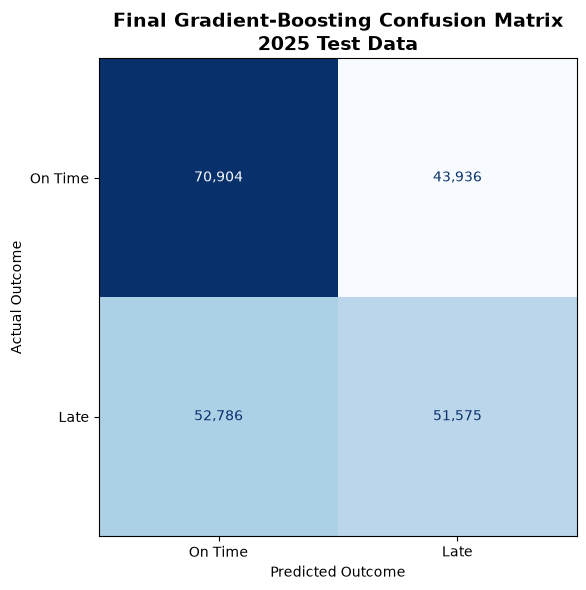

In [82]:
# generate confusion matrix visulization

fig, ax = plt.subplots(figsize=(7, 6))

ConfusionMatrixDisplay(
    confusion_matrix=final_confusion_matrix,
    display_labels=["On Time", "Late"]
).plot(
    cmap="Blues",
    values_format=",",
    colorbar=False,
    ax=ax
)

ax.set_title(
    "Final Gradient-Boosting Confusion Matrix\n"
    "2025 Test Data",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Predicted Outcome")
ax.set_ylabel("Actual Outcome")

plt.tight_layout()
plt.show()

In [83]:
true_negatives, false_positives, false_negatives, true_positives = (
    final_confusion_matrix.ravel()
)

confusion_matrix_summary = pd.Series({
    "True negatives": true_negatives,
    "False positives": false_positives,
    "False negatives": false_negatives,
    "True positives": true_positives
})

confusion_matrix_summary

True negatives     70904
False positives    43936
False negatives    52786
True positives     51575
dtype: int64

In [84]:
# generate logist regression on 2025 data to compare results against the gradient boost

final_logistic_model = (
    logistic_grid_search.best_estimator_
)

logistic_test_probabilities = (
    final_logistic_model.predict_proba(X_test)[:, 1]
)

diagnostic_test_comparison = pd.DataFrame({
    "Model": [
        "Logistic regression",
        "Gradient boosting"
    ],
    "2025 ROC-AUC": [
        roc_auc_score(
            y_test,
            logistic_test_probabilities
        ),
        roc_auc_score(
            y_test,
            final_test_probabilities
        )
    ],
    "2025 PR-AUC": [
        average_precision_score(
            y_test,
            logistic_test_probabilities
        ),
        average_precision_score(
            y_test,
            final_test_probabilities
        )
    ],
    "2025 Brier score": [
        brier_score_loss(
            y_test,
            logistic_test_probabilities
        ),
        brier_score_loss(
            y_test,
            final_test_probabilities
        )
    ]
})

diagnostic_test_comparison.round(4)

,Model,2025 ROC-AUC,2025 PR-AUC,2025 Brier score
0,Logistic regression,0.6130,0.6016,0.2515
1,Gradient boosting,0.6186,0.6051,0.2468


Interpret the Model

In [85]:
# calculate feature importance

permutation_results = permutation_importance(
    estimator=final_model,
    X=X_test,
    y=y_test,
    scoring="roc_auc",
    n_repeats=5,
    random_state=42,
    n_jobs=1
)

feature_importance = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean":
        permutation_results.importances_mean,
    "importance_std":
        permutation_results.importances_std
}).sort_values(
    "importance_mean",
    ascending=False
)

feature_importance.round(4)

,feature,importance_mean,importance_std
2,agency_responsible,0.0823,0.0008
0,service_type,0.0237,0.0003
3,zipcode_clean,0.0051,0.0001
8,expected_service_days,0.0039,0.0003
4,request_month,0.0027,0.0002
7,is_weekend,0.0000,0.0000
5,request_day_of_week,0.0000,0.0000
6,request_hour,0.0000,0.0000
1,service_code,-0.0036,0.0003


In [86]:
# rank 2025 requests by predicted probability

ranked_2025_requests = (
    test_data
    .reset_index()
    .rename(columns={"index": "original_index"})
    .copy()
)

ranked_2025_requests["predicted_late_probability"] = (
    final_test_probabilities
)

ranked_2025_requests["predicted_outcome"] = np.where(
    final_test_probabilities >= 0.50,
    "Predicted late",
    "Predicted on time"
)

ranked_2025_requests["risk_percentile"] = (
    ranked_2025_requests[
        "predicted_late_probability"
    ]
    .rank(
        method="average",
        pct=True
    )
    .mul(100)
)

ranked_2025_requests = (
    ranked_2025_requests
    .sort_values(
        "predicted_late_probability",
        ascending=False
    )
    .reset_index(drop=True)
)

ranking_columns = [
    "risk_rank",
    "service_request_id",
    "requested_datetime",
    "service_type",
    "service_code",
    "agency",
    "zipcode_clean",
    "expected_service_days",
    "predicted_late_probability",
    "risk_percentile",
    "predicted_outcome",
    "missed_deadline"
]

ranking_columns = [
    column
    for column in ranking_columns
    if column in ranked_2025_requests.columns
]

In [87]:
ranked_2025_requests[
    ranking_columns
].head(50)

,service_request_id,requested_datetime,service_type,service_code,zipcode_clean,expected_service_days,predicted_late_probability,risk_percentile,predicted_outcome,missed_deadline
0,15935822,2023-06-01 17:40:29+00:00,Property Maintenance Interior,NaN,19134,33.263553,0.897491,100.000000,Predicted late,1
1,15941908,2023-06-05 19:55:46+00:00,Property Maintenance Interior,NaN,19134,34.169606,0.890818,99.999544,Predicted late,1
2,16457768,2023-12-19 23:49:57+00:00,Property Maintenance Interior,NaN,19134,33.006979,0.887592,99.997491,Predicted late,1
3,16417732,2023-11-30 18:41:06+00:00,Property Maintenance Interior,NaN,19134,33.221458,0.887592,99.997491,Predicted late,1
4,16457543,2023-12-19 21:26:17+00:00,Property Maintenance Interior,NaN,19134,33.106748,0.887592,99.997491,Predicted late,1
5,16457708,2023-12-19 22:51:13+00:00,Property Maintenance Interior,NaN,19134,33.047766,0.887592,99.997491,Predicted late,1
6,16412497,2023-11-28 18:28:21+00:00,Property Maintenance Interior,NaN,19134,33.230313,0.887592,99.997491,Predicted late,1
7,16452136,2023-12-16 05:47:46+00:00,Property Maintenance Interior,NaN,19134,32.758495,0.887592,99.997491,Predicted late,1
8,16417720,2023-11-30 18:37:47+00:00,Property Maintenance Interior,NaN,19134,33.223762,0.887592,99.997491,Predicted late,1
9,16412023,2023-11-28 17:03:07+00:00,Property Maintenance Interior,NaN,19134,33.289502,0.887592,99.997491,Predicted late,1


In [88]:
# flag highest risk 10%

top_10_percent_count = int(
    np.ceil(len(ranked_2025_requests) * 0.10)
)

ranked_2025_requests["top_10_percent_risk"] = False

ranked_2025_requests.loc[
    :top_10_percent_count - 1,
    "top_10_percent_risk"
] = True

ranked_2025_requests[
    "top_10_percent_risk"
].value_counts()

top_10_percent_risk
False    197280
True      21921
Name: count, dtype: int64

In [89]:
# examine 10% highest risk requests

flagged_requests = (
    ranked_2025_requests.loc[
        ranked_2025_requests["top_10_percent_risk"]
    ]
    .sort_values(
        "predicted_late_probability",
        ascending=False
    )
    .copy()
)

flagged_columns = [
    "risk_rank",
    "service_request_id",
    "requested_datetime",
    "service_type",
    "service_code",
    "agency",
    "zipcode_clean",
    "expected_datetime",
    "expected_service_days",
    "predicted_late_probability",
    "missed_deadline"
]

flagged_columns = [
    column
    for column in flagged_columns
    if column in flagged_requests.columns
]

(
    flagged_requests[flagged_columns]
    .head(25)
    .style
    .format({
        "predicted_late_probability": "{:.1%}",
        "expected_service_days": "{:.1f}"
    })
)

,service_request_id,requested_datetime,service_type,service_code,zipcode_clean,expected_datetime,expected_service_days,predicted_late_probability,missed_deadline
0,15935822,2023-06-01 17:40:29+00:00,Property Maintenance Interior,nan,19134,2023-07-05 00:00:00+00:00,33.3,89.7%,1
1,15941908,2023-06-05 19:55:46+00:00,Property Maintenance Interior,nan,19134,2023-07-10 00:00:00+00:00,34.2,89.1%,1
2,16457768,2023-12-19 23:49:57+00:00,Property Maintenance Interior,nan,19134,2024-01-22 00:00:00+00:00,33.0,88.8%,1
4,16457543,2023-12-19 21:26:17+00:00,Property Maintenance Interior,nan,19134,2024-01-22 00:00:00+00:00,33.1,88.8%,1
5,16457708,2023-12-19 22:51:13+00:00,Property Maintenance Interior,nan,19134,2024-01-22 00:00:00+00:00,33.0,88.8%,1
6,16412497,2023-11-28 18:28:21+00:00,Property Maintenance Interior,nan,19134,2024-01-01 00:00:00+00:00,33.2,88.8%,1
7,16452136,2023-12-16 05:47:46+00:00,Property Maintenance Interior,nan,19134,2024-01-18 00:00:00+00:00,32.8,88.8%,1
8,16417720,2023-11-30 18:37:47+00:00,Property Maintenance Interior,nan,19134,2024-01-03 00:00:00+00:00,33.2,88.8%,1
9,16412023,2023-11-28 17:03:07+00:00,Property Maintenance Interior,nan,19134,2024-01-01 00:00:00+00:00,33.3,88.8%,1
3,16417732,2023-11-30 18:41:06+00:00,Property Maintenance Interior,nan,19134,2024-01-03 00:00:00+00:00,33.2,88.8%,1


In [90]:
# measure operational value of flagged late requests

overall_late_rate = (
    ranked_2025_requests["missed_deadline"].mean()
)

flagged_late_rate = (
    flagged_requests["missed_deadline"].mean()
)

late_requests_identified = (
    flagged_requests["missed_deadline"].sum()
)

total_late_requests = (
    ranked_2025_requests["missed_deadline"].sum()
)

flagged_summary = pd.Series({
    "requests_flagged": len(flagged_requests),
    "actual_late_requests_flagged":
        late_requests_identified,

    "flagged_group_late_rate":
        flagged_late_rate,

    "overall_late_rate":
        overall_late_rate,

    "share_of_all_late_requests_identified":
        late_requests_identified / total_late_requests,

    "lift_over_average":
        flagged_late_rate / overall_late_rate
})

flagged_summary.round(4)

requests_flagged                         21921.0000
actual_late_requests_flagged             16620.0000
flagged_group_late_rate                      0.7582
overall_late_rate                            0.4761
share_of_all_late_requests_identified        0.1593
lift_over_average                            1.5925
dtype: float64

In [91]:
# summarize flagged requests by agency

flagged_by_agency = (
    flagged_requests
    .groupby("agency_responsible")
    .agg(
        flagged_requests=("service_request_id", "size"),
        actual_late_requests=("missed_deadline", "sum"),
        flagged_group_late_rate=("missed_deadline", "mean"),
        average_predicted_risk=(
            "predicted_late_probability",
            "mean"
        )
    )
    .sort_values("flagged_requests", ascending=False)
)

flagged_by_agency.head(20).round(4)

,flagged_requests,actual_late_requests,flagged_group_late_rate,average_predicted_risk
agency_responsible,,,,
License & Inspections,11461,10052,0.8771,0.8192
Streets Department,5881,4536,0.7713,0.7649
Police Department,4568,2021,0.4424,0.7770
Parks & Recreation,10,10,1.0000,0.7648
Philly311 Contact Center,1,1,1.0000,0.7475


In [92]:
# summarize flagged requests by service type

flagged_by_service_type = (
    flagged_requests
    .groupby("service_type")
    .agg(
        flagged_requests=("service_request_id", "size"),
        actual_late_requests=("missed_deadline", "sum"),
        flagged_group_late_rate=("missed_deadline", "mean"),
        average_predicted_risk=(
            "predicted_late_probability",
            "mean"
        )
    )
    .sort_values("flagged_requests", ascending=False)
)

flagged_by_service_type.head(20).round(4)

,flagged_requests,actual_late_requests,flagged_group_late_rate,average_predicted_risk
service_type,,,,
Property Maintenance Interior,5541,4664,0.8417,0.8356
Pothole Repair,5371,4282,0.7972,0.7651
Abandoned Vehicle,4568,2021,0.4424,0.7770
Vacant Property,4533,4300,0.9486,0.8167
Residence without heat (October 1 to April 15th),701,651,0.9287,0.7730
Exterior High Weeds,340,196,0.5765,0.7515
Alley Light Outage,305,58,0.1902,0.7609
Property Maintenance Exterior,170,115,0.6765,0.7474
Broken Main Drain/Raw Sewage within Property,157,116,0.7389,0.7524


In [93]:
# calculate observed 2025 ROC-AUC

y_test_array = np.asarray(y_test, dtype=int)
test_probability_array = np.asarray(
    final_test_probabilities,
    dtype=float
)

observed_auc = roc_auc_score(
    y_test_array,
    test_probability_array
)

print(f"Observed 2025 ROC-AUC: {observed_auc:.4f}")

Observed 2025 ROC-AUC: 0.6186


In [94]:
# generate bootstrap samples

rng = np.random.default_rng(42)

positive_indices = np.where(
    y_test_array == 1
)[0]

negative_indices = np.where(
    y_test_array == 0
)[0]

bootstrap_aucs = []

number_of_bootstraps = 1000

for _ in range(number_of_bootstraps):

    sampled_positive_indices = rng.choice(
        positive_indices,
        size=len(positive_indices),
        replace=True
    )

    sampled_negative_indices = rng.choice(
        negative_indices,
        size=len(negative_indices),
        replace=True
    )

    sampled_indices = np.concatenate([
        sampled_positive_indices,
        sampled_negative_indices
    ])

    bootstrap_auc = roc_auc_score(
        y_test_array[sampled_indices],
        test_probability_array[sampled_indices]
    )

    bootstrap_aucs.append(bootstrap_auc)

bootstrap_aucs = np.asarray(bootstrap_aucs)

In [95]:
# calculate 95% confidence interval

lower_bound = np.percentile(
    bootstrap_aucs,
    2.5
)

upper_bound = np.percentile(
    bootstrap_aucs,
    97.5
)

print(f"Observed ROC-AUC: {observed_auc:.4f}")
print(
    "95% bootstrap confidence interval: "
    f"({lower_bound:.4f}, {upper_bound:.4f})"
)

Observed ROC-AUC: 0.6186
95% bootstrap confidence interval: (0.6162, 0.6211)


In [96]:
auc_confidence_interval = pd.DataFrame({
    "Metric": ["ROC-AUC"],
    "Observed value": [observed_auc],
    "Lower 95% bound": [lower_bound],
    "Upper 95% bound": [upper_bound],
    "No-skill value": [0.50]
})

auc_confidence_interval.round(4)

,Metric,Observed value,Lower 95% bound,Upper 95% bound,No-skill value
0,ROC-AUC,0.6186,0.6162,0.6211,0.5


In [97]:
# evaluate hypothesis

if lower_bound > 0.50:
    print(
        "Reject the null hypothesis: "
        "the final model's ROC-AUC is significantly "
        "greater than 0.50."
    )
else:
    print(
        "Fail to reject the null hypothesis: "
        "the confidence interval does not establish "
        "that ROC-AUC is greater than 0.50."
    )

Reject the null hypothesis: the final model's ROC-AUC is significantly greater than 0.50.
